# Carbon Investment Widget (mock-up)

In [2]:
#import libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [3]:
carbon_data = pd.read_csv('../../../data/carbon_investment.csv')
metadata_carbon = {'ISO':carbon_data.columns[0] , 'Country':carbon_data.columns[1], 'Carbon_5_txt':carbon_data.columns[2], 'Carbon_5_area':carbon_data.columns[3],
                    'Carbon_10_txt':carbon_data.columns[4], 'Carbon_10_area':carbon_data.columns[5],'Diff_carbon_5_10':carbon_data.columns[6], 'Protected_area':carbon_data.columns[7], 'Remaining_area':carbon_data.columns[8]}
carbon_data.columns = ['ISO', 'Country', 'Carbon_5_txt', 'Carbon_5_area', 'Carbon_10_txt', 'Carbon_10_area','Diff_carbon_5_10','Protected_area', 'Remaining_area']
carbon_data['Carbon_5_area'] = carbon_data['Carbon_5_area'].str.replace(',', '').astype(np.float64)
carbon_data['Carbon_10_area'] = carbon_data['Carbon_10_area'].str.replace(',', '').astype(np.float64)
carbon_data['Remaining_area'] = carbon_data['Remaining_area'].str.replace(',', '').astype(np.float64)
#carbon_data.set_index('ISO', inplace = True)
carbon_data

,ISO,Country,Carbon_5_txt,Carbon_5_area,Carbon_10_txt,Carbon_10_area,Diff_carbon_5_10,Protected_area,Remaining_area
0,AGO,Angola,900 (±100),900.0,"1,300 (± 100)",1300.0,400,168.7598,35058.97
1,ATG,Antigua & Barbuda,0.00,0.0,0.00,0.0,0,444.4700,445.21
2,AUS,Australia,0.00,0.0,0.00,0.0,0,484299.6015,482962.98
3,BHR,Bahrain,0.00,0.0,0.00,0.0,0,0.0000,82.03
4,BGD,Bangladesh,"98,900 (±2,800)",98900.0,"113,700 (± 3,200)",113700.0,14800,375201.7996,0.00
...,...,...,...,...,...,...,...,...,...
96,VUT,Vanuatu,0,0.0,0,0.0,0,0.0000,1769.02
97,VEN,Venezuela,"3,000 (±700)",3000.0,"8,400 (± 2,000)",8400.0,5400,185790.9775,85414.87
98,VNM,Vietnam,"75,900 (±3,200)",75900.0,"90,900 (± 3,800)",90900.0,15000,73507.8649,0.00
99,VGB,"Virgin Islands, British",0,0.0,0,0.0,0,0.0000,87.21


In [4]:
carbon_data.dtypes

ISO                  object
Country              object
Carbon_5_txt         object
Carbon_5_area       float64
Carbon_10_txt        object
Carbon_10_area      float64
Diff_carbon_5_10      int64
Protected_area      float64
Remaining_area      float64
dtype: object

## 1. Data visualization test

In [4]:
ind_data = carbon_data[carbon_data['Country'] == 'Indonesia'].copy()
ind_data

,ISO,Country,Carbon_5_txt,Carbon_5_area,Carbon_10_txt,Carbon_10_area,Diff_carbon_5_10,Protected_area,Remaining_area
40,IDN,Indonesia,"325,400 (±21,100)",325400.0,"427,600 (± 27,700)",427600.0,102200,657439.3765,1565772.55


In [5]:
plot_data = ind_data.drop(columns = ['ISO','Country', 'Carbon_5_txt', 'Carbon_10_txt', 'Diff_carbon_5_10']).T
plot_data.columns = ['area']
plot_data

,area
Carbon_5_area,3.254000e+05
Carbon_10_area,4.276000e+05
Protected_area,6.574394e+05
Remaining_area,1.565773e+06


Indonesia: Extent of investible blue carbon (ha) is 325,400 (±21,100) (at $5/ton)




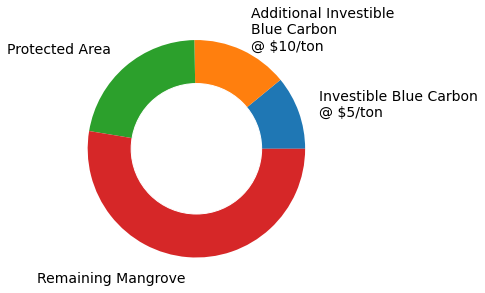

In [6]:
print(f'{ind_data.iloc[0,1]}: Extent of investible blue carbon (ha) is {ind_data.iloc[0,2]} (at $5/ton)\n\n')

plt.rcParams['figure.figsize'] = [5, 5]
labs = ['Investible Blue Carbon\n@ $5/ton', 'Additional Investible\nBlue Carbon\n@ $10/ton', 'Protected Area',  'Remaining Mangrove']

# Create a pieplot
plt.pie(plot_data['area'], labels=labs, labeldistance=1.2, textprops={'fontsize' : 14})
# add a circle at the center to transform it in a donut chart
my_circle=plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

plt.show()

## 2. Prepare data model.  
The proposed data model is:

- id [int]  
- location_id [str]  
- category [str]  (column name might need to change to be more descriptive)  
- area [numeric]  
- text [str]  

### 2.1) Add location IDs to the data

In [3]:
#dataLocation = requests.get('https://mangrove-atlas-api.herokuapp.com/api/v2/locations').json()['data']
#locations = pd.DataFrame(dataLocation)
#locations = locations[locations['location_type'] == 'country']
#locations.rename(columns={'iso':'ISO'}, inplace = True)
#locations.head()

,id,ISO,bounds,location_type,name,area_m2,perimeter_m,coast_length_m,location_id
3,992,AGO,"{'coordinates': [[[8.20187877548665, -18.01639...",country,Angola,1.744005e+12,7.368212e+06,2007891.49,1_2_97
4,964,ATG,"{'coordinates': [[[-62.753156503651574, 16.613...",country,Antigua & Barbuda,1.087145e+11,1.465019e+06,310741.81,1_2_69
9,993,AUS,"{'coordinates': [[[109.23347930458496, -58.449...",country,Australia,1.512101e+13,1.958652e+07,64705984.16,1_2_98
11,968,BHR,"{'coordinates': [[[50.26972033926273, 25.53500...",country,Bahrain,8.300804e+09,4.422017e+05,817872.85,1_2_73
12,967,BGD,"{'coordinates': [[[88.04387122416243, 18.56519...",country,Bangladesh,2.239512e+11,3.223121e+06,6054280.79,1_2_72


In [7]:
locations = pd.read_csv('../../../data/staging_locations.csv')
locations = locations[locations['location_type'] == 'country']
locations.rename(columns={'iso':'ISO'}, inplace = True)
locations.head()

,id,name,location_type,ISO,bounds,geometry,area_m2,perimeter_m,created_at,updated_at,coast_length_m,location_id
159,1402,Dominican Republic,country,DOM,"{""coordinates""=>[[[-73.45833445927934, 14.9644...","{""type""=>""Polygon"", ""coordinates""=>[[[-73.4583...",3.185563e+11,2.708915e+06,2020-07-22 18:10:58 UTC,2020-07-22 18:10:58 UTC,1719584.27,1_2_101
160,1401,Colombia,country,COL,"{""coordinates""=>[[[-84.7666682890813, -4.23687...","{""type""=>""MultiPolygon"", ""coordinates""=>[[[[-8...",1.870887e+12,1.056859e+07,2020-07-22 18:10:58 UTC,2020-07-22 18:10:58 UTC,7309379.81,1_2_100
161,1400,"Congo, DRC",country,COD,"{""coordinates""=>[[[9.00732615998469, -13.45805...","{""type""=>""Polygon"", ""coordinates""=>[[[9.007326...",2.350668e+12,9.973317e+06,2020-07-22 18:10:58 UTC,2020-07-22 18:10:58 UTC,41591.51,1_2_99
162,1399,Australia,country,AUS,"{""coordinates""=>[[[109.23347930458496, -58.449...","{""type""=>""MultiPolygon"", ""coordinates""=>[[[[15...",1.512101e+13,1.958652e+07,2020-07-22 18:10:58 UTC,2020-07-22 18:10:58 UTC,64705984.16,1_2_98
163,1398,Angola,country,AGO,"{""coordinates""=>[[[8.20187877548665, -18.01639...","{""type""=>""MultiPolygon"", ""coordinates""=>[[[[9....",1.744005e+12,7.368212e+06,2020-07-22 18:10:58 UTC,2020-07-22 18:10:58 UTC,2007891.49,1_2_97


In [8]:
id_field = 'id'
loc = locations[[id_field, 'ISO', 'name']]
loc.head()

,id,ISO,name
159,1402,DOM,Dominican Republic
160,1401,COL,Colombia
161,1400,COD,"Congo, DRC"
162,1399,AUS,Australia
163,1398,AGO,Angola


In [9]:
df = pd.merge(carbon_data, loc, on= 'ISO', how= 'left')
df = df[['ISO', id_field, 'name','Country','Carbon_5_txt','Carbon_5_area','Carbon_10_txt','Carbon_10_area','Diff_carbon_5_10','Protected_area','Remaining_area']]
df.columns = df.columns.str.lower()
df.rename(columns={'name':'location'}, inplace=True)
df.drop(columns='country', inplace=True)
df

,iso,id,location,carbon_5_txt,carbon_5_area,carbon_10_txt,carbon_10_area,diff_carbon_5_10,protected_area,remaining_area
0,AGO,1398,Angola,900 (±100),900.0,"1,300 (± 100)",1300.0,400,168.7598,35058.97
1,ATG,1370,Antigua & Barbuda,0.00,0.0,0.00,0.0,0,444.4700,445.21
2,AUS,1399,Australia,0.00,0.0,0.00,0.0,0,484299.6015,482962.98
3,BHR,1374,Bahrain,0.00,0.0,0.00,0.0,0,0.0000,82.03
4,BGD,1373,Bangladesh,"98,900 (±2,800)",98900.0,"113,700 (± 3,200)",113700.0,14800,375201.7996,0.00
...,...,...,...,...,...,...,...,...,...,...
96,VUT,1394,Vanuatu,0,0.0,0,0.0,0,0.0000,1769.02
97,VEN,1362,Venezuela,"3,000 (±700)",3000.0,"8,400 (± 2,000)",8400.0,5400,185790.9775,85414.87
98,VNM,1364,Vietnam,"75,900 (±3,200)",75900.0,"90,900 (± 3,800)",90900.0,15000,73507.8649,0.00
99,VGB,1363,"Virgin Islands, British",0,0.0,0,0.0,0,0.0000,87.21


### 2.2) Format data and combine into final dataframe.    

Function to select only columns of interest and create the "area" and "category" fields accordingly

In [10]:
def prep_data(df, var):
    label = var.replace('_area', '').replace('_txt', '')
    vars_select = ['location', id_field, var]
    df_select = df[vars_select].copy()
    if '_area' in var:
        df_select['area'] = df_select[var]
        df_select['category'] = label
        df_select = df_select[['location', id_field, 'category', 'area']]
        #df_select.rename(columns={'country':'id'}, inplace=True)
    else:
        df_select['text_val'] = df_select[var]
        df_select['category'] = label
        df_select = df_select[['location', id_field, 'category', 'text_val']]
        #df_select.rename(columns={'country':'id'}, inplace=True)
    
    return df_select
    


In [12]:
var = 'carbon_5_txt'
t = prep_data(df, var)
t

,location,id,category,text_val
0,Angola,1398,carbon_5,900 (±100)
1,Antigua & Barbuda,1370,carbon_5,0.00
2,Australia,1399,carbon_5,0.00
3,Bahrain,1374,carbon_5,0.00
4,Bangladesh,1373,carbon_5,"98,900 (±2,800)"
...,...,...,...,...
96,Vanuatu,1394,carbon_5,0
97,Venezuela,1362,carbon_5,"3,000 (±700)"
98,Vietnam,1364,carbon_5,"75,900 (±3,200)"
99,"Virgin Islands, British",1363,carbon_5,0


Combine all numeric variables

In [13]:
df_num = pd.concat([prep_data(df, 'carbon_5_area'),
                    prep_data(df, 'carbon_10_area'),
                    prep_data(df, 'protected_area'),
                    prep_data(df, 'remaining_area')])
df_num.reset_index(drop=True, inplace=True)
df_num

,location,id,category,area
0,Angola,1398,carbon_5,900.00
1,Antigua & Barbuda,1370,carbon_5,0.00
2,Australia,1399,carbon_5,0.00
3,Bahrain,1374,carbon_5,0.00
4,Bangladesh,1373,carbon_5,98900.00
...,...,...,...,...
399,Vanuatu,1394,remaining,1769.02
400,Venezuela,1362,remaining,85414.87
401,Vietnam,1364,remaining,0.00
402,"Virgin Islands, British",1363,remaining,87.21


Combine text variables

In [14]:
df_txt = pd.concat([prep_data(df, 'carbon_5_txt'),
                    prep_data(df, 'carbon_10_txt')])
df_txt.reset_index(drop=True, inplace=True)
df_txt['description'] = ''

df_txt

,location,id,category,text_val,description
0,Angola,1398,carbon_5,900 (±100),
1,Antigua & Barbuda,1370,carbon_5,0.00,
2,Australia,1399,carbon_5,0.00,
3,Bahrain,1374,carbon_5,0.00,
4,Bangladesh,1373,carbon_5,"98,900 (±2,800)",
...,...,...,...,...,...
197,Vanuatu,1394,carbon_10,0,
198,Venezuela,1362,carbon_10,"8,400 (± 2,000)",
199,Vietnam,1364,carbon_10,"90,900 (± 3,800)",
200,"Virgin Islands, British",1363,carbon_10,0,


In [15]:
for i in range(len(df_txt[df_txt['category'] == 'carbon_5'])-1):
    if (df_txt['text_val'][i] != '0') & (df_txt['text_val'][i] != '0.00'):
        df_txt['description'][i] = str(f'{df_txt["location"][i]} extent of investible blue carbon (ha) is {df_txt["text_val"][i]} (at $5/ton)')

df_txt.drop(columns='text_val', inplace=True)
df_txt

/var/folders/wf/_wlxc6cn5js4hh3j7j6x28f80000gn/T/ipykernel_3957/272370122.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_txt['description'][i] = str(f'{df_txt["location"][i]} extent of investible blue carbon (ha) is {df_txt["text_val"][i]} (at $5/ton)')


,location,id,category,description
0,Angola,1398,carbon_5,Angola extent of investible blue carbon (ha) i...
1,Antigua & Barbuda,1370,carbon_5,
2,Australia,1399,carbon_5,
3,Bahrain,1374,carbon_5,
4,Bangladesh,1373,carbon_5,Bangladesh extent of investible blue carbon (h...
...,...,...,...,...
197,Vanuatu,1394,carbon_10,
198,Venezuela,1362,carbon_10,
199,Vietnam,1364,carbon_10,
200,"Virgin Islands, British",1363,carbon_10,


Combine numeric and text fields for final data

In [16]:
df_final = pd.merge(df_num, df_txt, on=['location', id_field, 'category'], how= 'left')
df_final.rename(columns={id_field:'location_id'}, inplace=True)
df_final

,location,location_id,category,area,description
0,Angola,1398,carbon_5,900.00,Angola extent of investible blue carbon (ha) i...
1,Antigua & Barbuda,1370,carbon_5,0.00,
2,Australia,1399,carbon_5,0.00,
3,Bahrain,1374,carbon_5,0.00,
4,Bangladesh,1373,carbon_5,98900.00,Bangladesh extent of investible blue carbon (h...
...,...,...,...,...,...
399,Vanuatu,1394,remaining,1769.02,NaN
400,Venezuela,1362,remaining,85414.87,NaN
401,Vietnam,1364,remaining,0.00,NaN
402,"Virgin Islands, British",1363,remaining,87.21,NaN


In [17]:
df_final[df_final['location'] == 'Indonesia']

,location,location_id,category,area,description
40,Indonesia,1334,carbon_5,3.254000e+05,Indonesia extent of investible blue carbon (ha...
141,Indonesia,1334,carbon_10,4.276000e+05,
242,Indonesia,1334,protected,6.574394e+05,NaN
343,Indonesia,1334,remaining,1.565773e+06,NaN


In [18]:
df_final.drop(columns='location', inplace=True)
df_final

,location_id,category,area,description
0,1398,carbon_5,900.00,Angola extent of investible blue carbon (ha) i...
1,1370,carbon_5,0.00,
2,1399,carbon_5,0.00,
3,1374,carbon_5,0.00,
4,1373,carbon_5,98900.00,Bangladesh extent of investible blue carbon (h...
...,...,...,...,...
399,1394,remaining,1769.02,NaN
400,1362,remaining,85414.87,NaN
401,1364,remaining,0.00,NaN
402,1363,remaining,87.21,NaN


In [19]:
df_final.dtypes

location_id      int64
category        object
area           float64
description     object
dtype: object

In [20]:
df_final.to_csv('../../../data/blue_carbon_investment_data_model.csv', index=False)